# RideSmart — Modelagem e Análise de Rotas Urbanas com Grafos

## Projeto Final — Algoritmos e Estrutura de Dados II (DCA3702)

**Universidade Federal do Rio Grande do Norte (UFRN) — 2026.1**
**Professor:** Ivanovitch Silva

**Autores:** Matheus Fernandes e Thales Varela

---

## 1. Visão Geral

Este notebook implementa o sistema **RideSmart**, uma simulação de aplicativo de mobilidade urbana que, dado:
- um ponto de origem **A**,
- um ponto de destino **B**, e
- uma distância máxima de caminhada **X**,

decide o **melhor ponto de embarque P** considerando o trade-off entre caminhar mais e chegar mais rápido.

O modelo de rota é:

```
A ──(caminhada ≤ X metros)──> P ──(carro)──> B
```

A análise compara **5 cenários** de decisão e **4 algoritmos** de caminho mínimo aplicados à malha viária real de **Coophab/Cajupiranga (Parnamirim/RN)**.

## 2. Problema e Objetivos

### Os 5 cenários comparados

| # | Cenário | Função de custo | Pergunta que responde |
|---|---|---|---|
| 1 | Menor distância | `length` | Qual rota tem menos quilômetros? |
| 2 | Mais rápida sem trânsito | `travel_time` | Em vias livres, qual é a mais rápida? |
| 3 | Mais rápida com trânsito | `travel_time_traffic` | Considerando congestionamento, qual é melhor? |
| 4 | Sem caminhada (P = A) | `travel_time_traffic` | Baseline: ir direto sem caminhar. |
| 5 | Ganho por caminhar | comparação #4 vs ótimo | Vale a pena andar X metros para ganhar tempo? |

### Os 4 algoritmos implementados

1. **Dijkstra simples** — O(V² + E), busca linear pelo menor não-visitado.
2. **Dijkstra com Min-Heap** — O((V + E) · log V), priority queue.
3. **A\*** — Dijkstra guiado por heurística geográfica (great-circle).
4. **Dijkstra Bidirecional** — expande de A e de B simultaneamente; algoritmo adicional da literatura.

### Objetivos de aprendizagem

- Modelar uma rede urbana real como grafo com múltiplos pesos.
- Implementar e comparar algoritmos clássicos de caminho mínimo **do zero**.
- Analisar o impacto da escolha do peso e do trânsito sobre a rota ótima.
- Quantificar o trade-off entre caminhar e chegar mais rápido.

## 3. Região de Estudo

A análise reaproveita a mesma região do trabalho da Unidade 2 (T1U2), por **continuidade analítica**: a topologia da rede já foi caracterizada estruturalmente (1327 nós, 1917 arestas, k-core máximo = 2, bridge node `3454188414` identificado), e agora aplicamos algoritmos de routing sobre essa malha conhecida.

**Coordenadas centrais:** (-5.908906, -35.205872) — Parque das Árvores, Parnamirim/RN
**Raio:** 3 km
**Bairros cobertos:** Nova Parnamirim (norte), Parque das Árvores, Parque das Nações, Coophab/Cajupiranga (sul), além do Parque do Jiqui e Jiqui Country Club a leste.

A divisão norte/sul é estruturada pela **Avenida Olavo Montenegro**, que será um corredor crítico nas rotas testadas.

## 4. Setup — Instalação e Imports

Instalamos o OSMnx (manipula redes viárias do OpenStreetMap) e o folium (mapas interativos). As demais bibliotecas (NetworkX, Matplotlib, NumPy, Pandas) já vêm pré-instaladas no Google Colab.

In [ ]:
!pip install osmnx folium --quiet

import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
import heapq
import random
import math
import time
import os
from collections import defaultdict

# Cria pasta de imagens se não existir (necessário no Colab)
os.makedirs("imagens", exist_ok=True)

# Seed global para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"OSMnx versão: {ox.__version__}")
print(f"NetworkX versão: {nx.__version__}")
print(f"Seed fixa: {SEED}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.3 MB/s eta 0:00:00
OSMnx versão: 2.1.0
NetworkX versão: 3.6.1
Seed fixa: 42


## 5. Construção do Grafo com OSMnx

Baixamos a malha viária real da região centrada em **(-5.908906, -35.205872)** com raio de **3 km**.

O OSMnx devolve um grafo direcionado (`MultiDiGraph`), porque ruas têm sentido. Como o problema RideSmart trabalha com rotas práticas (sem distinção de mão única para simplificar), vamos converter para um grafo simples não-direcionado nas análises.

In [ ]:
ponto_central = (-5.908906, -35.205872)
raio_metros = 3000

print("Baixando malha viária do OpenStreetMap...")
G_dir = ox.graph_from_point(ponto_central, dist=raio_metros, network_type="drive")

# Adiciona velocidades e tempos de viagem usando defaults do OSMnx por tipo de via
G_dir = ox.add_edge_speeds(G_dir)
G_dir = ox.add_edge_travel_times(G_dir)

print(f"\nGrafo direcionado (MultiDiGraph):")
print(f"  Nós: {G_dir.number_of_nodes()}")
print(f"  Arestas: {G_dir.number_of_edges()}")

Baixando malha viária do OpenStreetMap...

Grafo direcionado (MultiDiGraph):
  Nós: 1342
  Arestas: 3229


### 5.1 Conversão para grafo simples não-direcionado

Para garantir consistência metodológica e evitar arestas paralelas:
1. Convertemos para não-direcionado com `ox.convert.to_undirected`.
2. Convertemos para `nx.Graph` simples (`nx.Graph(G_undirected)` colapsa multi-arestas).
3. Validamos a conectividade, caso contrário, métricas como caminho mínimo entre certos pares ficariam indefinidas.

Quando colapsamos multi-arestas, escolhemos a aresta de **menor comprimento** entre cada par de nós (a "rua mais curta"), o que é coerente com o problema.

In [ ]:
# Passo 1: para não-direcionado (ainda MultiGraph)
G_undirected = ox.convert.to_undirected(G_dir)

# Passo 2: para grafo simples, mantendo a aresta de menor 'length' entre nós
G = nx.Graph()
G.add_nodes_from(G_undirected.nodes(data=True))
for u, v, data in G_undirected.edges(data=True):
    if G.has_edge(u, v):
        # já existe — manter a de menor length
        if data.get('length', float('inf')) < G[u][v].get('length', float('inf')):
            G[u][v].update(data)
    else:
        G.add_edge(u, v, **data)

print(f"Grafo simples (nx.Graph):")
print(f"  Nós: {G.number_of_nodes()}")
print(f"  Arestas: {G.number_of_edges()}")
print(f"  Componentes conectados: {nx.number_connected_components(G)}")
print(f"  Conexo? {nx.is_connected(G)}")

# Se não estiver conectado, ficamos só com o componente gigante
if not nx.is_connected(G):
    maior_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(maior_cc).copy()
    print(f"\nMantido apenas componente gigante: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

Grafo simples (nx.Graph):
  Nós: 1342
  Arestas: 1936
  Componentes conectados: 1
  Conexo? True


## 6. Múltiplos Pesos nas Arestas

Cada aresta do grafo precisa ter **três pesos** para os 5 cenários da análise:

| Peso | Significado | Origem |
|---|---|---|
| `length` | Comprimento real da rua em metros | já vem do OSMnx |
| `travel_time` | Tempo de viagem em segundos (vias livres) | calculado pelo OSMnx via `add_edge_travel_times` |
| `travel_time_traffic` | Tempo com trânsito sintético | calculado na Fase 2 abaixo |

Vamos garantir que `length` e `travel_time` estão presentes em todas as arestas.

In [ ]:
# Validar que length e travel_time existem em todas as arestas
faltam_length = sum(1 for _, _, d in G.edges(data=True) if 'length' not in d)
faltam_time = sum(1 for _, _, d in G.edges(data=True) if 'travel_time' not in d)

print(f"Arestas sem 'length': {faltam_length}")
print(f"Arestas sem 'travel_time': {faltam_time}")

# Estatísticas dos pesos base
lengths = [d['length'] for _, _, d in G.edges(data=True)]
times = [d['travel_time'] for _, _, d in G.edges(data=True)]

print(f"\nLength (metros):    média={np.mean(lengths):.1f}, mín={min(lengths):.1f}, máx={max(lengths):.1f}")
print(f"Travel time (seg):  média={np.mean(times):.1f}, mín={min(times):.1f}, máx={max(times):.1f}")

Arestas sem 'length': 0
Arestas sem 'travel_time': 0

Length (metros):    média=93.0, mín=0.6, máx=1780.6
Travel time (seg):  média=10.1, mín=0.0, máx=105.6


## 7. Modelo de Trânsito Sintético

O OSMnx fornece `travel_time` em condições ideais (sem trânsito). Para simular congestionamento de **hora de pico**, aplicamos um modelo em camadas:

```
travel_time_traffic = travel_time_base × multiplicador_tipo × ruído_aleatório
```

Onde:

- **`multiplicador_tipo`**: penaliza vias arteriais mais que residenciais. Avenidas como a Olavo Montenegro recebem multiplicadores ~2.0–2.5 porque concentram tráfego de toda a região. Ruas internas de loteamento ficam em ~1.0–1.2.
- **`ruído_aleatório`**: variação 0.8–1.5 amostrada com `random.seed(SEED)`, garantindo que todos os experimentos rodem com o mesmo trânsito.

Esse modelo é **defensável e reprodutível**: não é trânsito real, mas é um proxy razoável de congestionamento urbano coerente com a hierarquia viária.

In [ ]:
# Multiplicadores por tipo de via (highway tag do OSM)
# Multiplicadores calibrados para hora de pico SEVERA:
# vias arteriais ficam ate 4x mais lentas que o tempo livre.
# Isso amplifica o contraste entre arterial e residencial,
# criando oportunidade real para "desvio caminhando" valer a pena.
MULTIPLICADOR_TIPO = {
    'motorway':       4.0,   # autoestradas - pico severo
    'trunk':          3.8,
    'primary':        4.0,   # Av. Olavo Montenegro entupida
    'secondary':      2.8,   # avenidas secundarias congestionadas
    'tertiary':       2.2,
    'residential':    1.3,   # ruas internas - pouco afetadas
    'unclassified':   1.2,
    'living_street':  1.0,
    'service':        1.0,
}

def get_multiplicador(highway_tag):
    """Retorna o multiplicador para a tag de via. Aceita string ou lista (caso OSM)."""
    if isinstance(highway_tag, list):
        # algumas arestas têm lista de tipos — usa o mais alto
        return max(MULTIPLICADOR_TIPO.get(h, 1.1) for h in highway_tag)
    return MULTIPLICADOR_TIPO.get(highway_tag, 1.1)

# Aplica o modelo em cada aresta
rng = random.Random(SEED)
for u, v, data in G.edges(data=True):
    base = data['travel_time']
    mult_tipo = get_multiplicador(data.get('highway', 'unclassified'))
    ruido = rng.uniform(0.9, 2.2)  # variacao ampla cria hot spots locais
    data['travel_time_traffic'] = base * mult_tipo * ruido

# Estatísticas comparativas
times_base = [d['travel_time'] for _, _, d in G.edges(data=True)]
times_traffic = [d['travel_time_traffic'] for _, _, d in G.edges(data=True)]

print(f"Travel time SEM trânsito:")
print(f"  Total da rede: {sum(times_base)/60:.1f} min")
print(f"  Média por aresta: {np.mean(times_base):.2f}s")
print(f"\nTravel time COM trânsito sintético:")
print(f"  Total da rede: {sum(times_traffic)/60:.1f} min")
print(f"  Média por aresta: {np.mean(times_traffic):.2f}s")
print(f"\nFator médio de aumento: {np.mean(times_traffic)/np.mean(times_base):.2f}x")

Travel time SEM trânsito:
  Total da rede: 327.0 min
  Média por aresta: 10.13s

Travel time COM trânsito sintético:
  Total da rede: 774.5 min
  Média por aresta: 24.00s

Fator médio de aumento: 2.37x


### 7.1 Visualização do trânsito sintético

Comparamos a distribuição dos tempos de viagem com e sem trânsito. Esperamos:
- A distribuição "com trânsito" deve estar **deslocada para a direita** (tempos maiores).
- A distribuição "com trânsito" deve ser **mais larga** (maior variância) devido ao multiplicador por tipo.

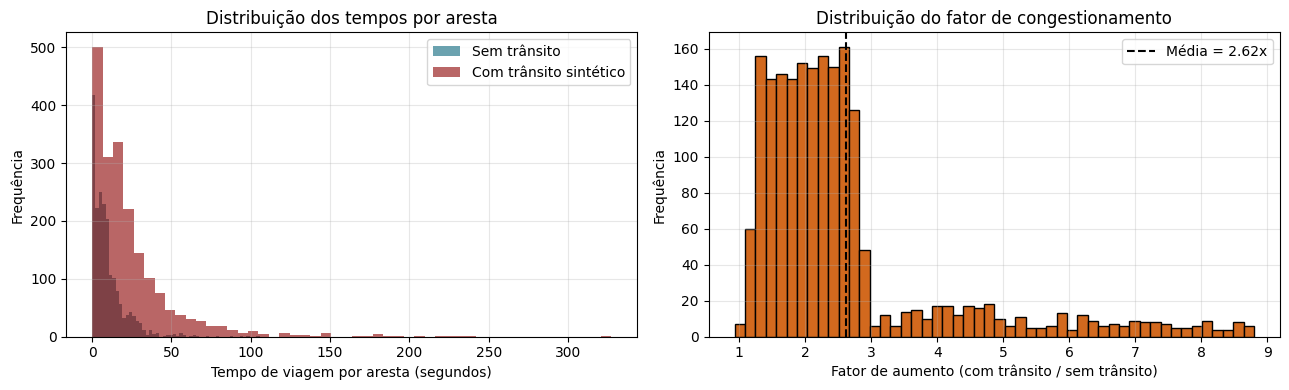

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(times_base, bins=50, color="#2C7B8E", alpha=0.7, label="Sem trânsito")
ax[0].hist(times_traffic, bins=50, color="#8B0000", alpha=0.6, label="Com trânsito sintético")
ax[0].set_xlabel("Tempo de viagem por aresta (segundos)")
ax[0].set_ylabel("Frequência")
ax[0].set_title("Distribuição dos tempos por aresta")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Razão de aumento por aresta
razoes = [t/b for t, b in zip(times_traffic, times_base)]
ax[1].hist(razoes, bins=50, color="#D2691E", edgecolor="black")
ax[1].axvline(np.mean(razoes), color="black", linestyle="--", label=f"Média = {np.mean(razoes):.2f}x")
ax[1].set_xlabel("Fator de aumento (com trânsito / sem trânsito)")
ax[1].set_ylabel("Frequência")
ax[1].set_title("Distribuição do fator de congestionamento")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("imagens/trafego_sintetico.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Implementação dos Algoritmos

Conforme exigido pelo enunciado, **implementamos os algoritmos do zero** (sem chamar `nx.shortest_path` ou `heapq` na lógica principal). Usamos `heapq` apenas internamente dentro da nossa classe `MinHeap`, para fins educacionais.

### 8.1 Min-Heap (estrutura de prioridade)

A `MinHeap` é a estrutura base que acelera Dijkstra de O(V²) para O((V+E)·log V). Implementamos como **array com índices** seguindo a convenção:

- pai de `i` = `(i-1) // 2`
- filho esquerdo = `2*i + 1`
- filho direito = `2*i + 2`

**Operações:**
- `push(item, priority)`: insere e faz `sift_up` — O(log n)
- `pop()`: remove o mínimo e faz `sift_down` — O(log n)
- `peek()`: lê o mínimo sem remover — O(1)

In [ ]:
class MinHeap:
    """Min-Heap implementada do zero usando array + operações sift up/down."""

    def __init__(self):
        self.heap = []  # lista de tuplas (priority, counter, item)
        self._counter = 0  # desempate para itens com mesma prioridade

    def __len__(self):
        return len(self.heap)

    def push(self, item, priority):
        """Insere item com a prioridade dada. O(log n)."""
        self.heap.append((priority, self._counter, item))
        self._counter += 1
        self._sift_up(len(self.heap) - 1)

    def pop(self):
        """Remove e devolve (priority, item) com menor prioridade. O(log n)."""
        if not self.heap:
            raise IndexError("pop em heap vazio")
        top = self.heap[0]
        last = self.heap.pop()
        if self.heap:
            self.heap[0] = last
            self._sift_down(0)
        return top[0], top[2]

    def peek(self):
        """Retorna o item de menor prioridade sem remover. O(1)."""
        return self.heap[0][2] if self.heap else None

    def _sift_up(self, i):
        while i > 0:
            parent = (i - 1) // 2
            if self.heap[i] < self.heap[parent]:
                self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
                i = parent
            else:
                break

    def _sift_down(self, i):
        n = len(self.heap)
        while True:
            left, right = 2 * i + 1, 2 * i + 2
            smallest = i
            if left < n and self.heap[left] < self.heap[smallest]:
                smallest = left
            if right < n and self.heap[right] < self.heap[smallest]:
                smallest = right
            if smallest != i:
                self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
                i = smallest
            else:
                break


# Teste rápido
h = MinHeap()
for valor in [5, 2, 8, 1, 9, 3]:
    h.push(f"item_{valor}", valor)

ordem_saida = []
while len(h) > 0:
    p, item = h.pop()
    ordem_saida.append(p)
print(f"Ordem de saída do MinHeap: {ordem_saida}")
assert ordem_saida == [1, 2, 3, 5, 8, 9], "MinHeap está com bug!"
print("✅ MinHeap validado.")

Ordem de saída do MinHeap: [1, 2, 3, 5, 8, 9]
✅ MinHeap validado.


### 8.2 Dijkstra Simples — O(V² + E)

Versão didática que **busca linearmente** o vértice não-visitado de menor distância a cada iteração. Não usa estrutura de prioridade.

A função devolve:
- `distancias`: dict {nó → custo mínimo do source até o nó}
- `predecessores`: dict {nó → nó anterior no caminho ótimo}
- `nos_expandidos`: contador para análise de eficiência

In [ ]:
def dijkstra_simples(G, source, weight="length"):
    """Dijkstra com busca linear pelo mínimo não-visitado. O(V^2 + E)."""
    distancias = {n: float('inf') for n in G.nodes()}
    predecessores = {n: None for n in G.nodes()}
    visitados = set()
    distancias[source] = 0
    nos_expandidos = 0

    while len(visitados) < len(G.nodes()):
        # Busca linear pelo nó não-visitado de menor distância
        u = None
        menor = float('inf')
        for n in G.nodes():
            if n not in visitados and distancias[n] < menor:
                menor = distancias[n]
                u = n

        if u is None:  # restantes são inalcançáveis
            break

        visitados.add(u)
        nos_expandidos += 1

        # Relaxa as arestas (u, v)
        for v in G.neighbors(u):
            if v in visitados:
                continue
            peso_aresta = G[u][v][weight]
            nova_dist = distancias[u] + peso_aresta
            if nova_dist < distancias[v]:
                distancias[v] = nova_dist
                predecessores[v] = u

    return distancias, predecessores, nos_expandidos


def reconstruir_caminho(predecessores, source, target):
    """Reconstrói o caminho de source até target seguindo o dict de predecessores."""
    if predecessores.get(target) is None and source != target:
        return None  # inalcançável
    caminho = []
    atual = target
    while atual is not None:
        caminho.append(atual)
        if atual == source:
            break
        atual = predecessores[atual]
    caminho.reverse()
    return caminho if caminho[0] == source else None

### 8.3 Dijkstra com Min-Heap — O((V + E) · log V)

Substitui a busca linear pela operação `pop` da `MinHeap` (O(log n) em vez de O(V)). Resultado: a complexidade total cai de O(V² + E) para O((V + E) · log V), o que é dramático em grafos grandes.

In [ ]:
def dijkstra_heap(G, source, weight="length"):
    """Dijkstra usando Min-Heap como priority queue. O((V+E) log V)."""
    distancias = {n: float('inf') for n in G.nodes()}
    predecessores = {n: None for n in G.nodes()}
    visitados = set()
    distancias[source] = 0
    nos_expandidos = 0

    pq = MinHeap()
    pq.push(source, 0)

    while len(pq) > 0:
        dist_u, u = pq.pop()
        if u in visitados:
            continue  # entrada obsoleta no heap
        visitados.add(u)
        nos_expandidos += 1

        for v in G.neighbors(u):
            if v in visitados:
                continue
            peso_aresta = G[u][v][weight]
            nova_dist = dist_u + peso_aresta
            if nova_dist < distancias[v]:
                distancias[v] = nova_dist
                predecessores[v] = u
                pq.push(v, nova_dist)

    return distancias, predecessores, nos_expandidos

### 8.4 A\* — Dijkstra guiado por heurística

A\* combina o custo real `g(n)` (do source até `n`) com uma **estimativa heurística** `h(n)` (de `n` até o goal). A função de avaliação é:

```
f(n) = g(n) + h(n)
```

**Heurística escolhida: Great-Circle Distance** (distância em linha reta sobre a esfera terrestre, calculada a partir de lat/long dos nós OSMnx).

**Por que great-circle?**
- Os nós têm coordenadas geográficas reais (atributos `y` = lat, `x` = lon).
- Great-circle é **admissível** quando o peso é distância em metros (`length`), pois é matematicamente impossível que a distância real seja menor que a distância em linha reta sobre a Terra.
- Para o peso `travel_time`, fazemos uma conversão: `h_tempo = great_circle / velocidade_máxima` (assumindo a maior velocidade possível na rede). Isso mantém admissibilidade.

 Quando a heurística não é admissível, A\* **não garante o ótimo**. Por isso é cuidadoso ajustar `h` para o peso usado.

In [ ]:
def great_circle(lat1, lon1, lat2, lon2):
    """Distância em metros entre dois pontos (haversine)."""
    R = 6371000.0  # raio da Terra em metros
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))


def fazer_heuristica(G, target, weight):
    """Cria função heurística admissível adequada para o peso usado."""
    target_lat = G.nodes[target]['y']
    target_lon = G.nodes[target]['x']

    if weight == "length":
        # h = distância em linha reta em metros
        def h(n):
            return great_circle(G.nodes[n]['y'], G.nodes[n]['x'], target_lat, target_lon)
    else:
        # h = distância em linha reta / velocidade máxima (segundos)
        # Para manter admissibilidade, dividimos pela maior velocidade observada no grafo.
        vmax_kmh = max(d.get('speed_kph', 50) for _, _, d in G.edges(data=True))
        vmax_ms = vmax_kmh / 3.6
        def h(n):
            d = great_circle(G.nodes[n]['y'], G.nodes[n]['x'], target_lat, target_lon)
            return d / vmax_ms
    return h


def a_star(G, source, target, weight="length"):
    """A* com heurística great-circle. Retorna distancias, predecessores, nos_expandidos."""
    h = fazer_heuristica(G, target, weight)
    distancias = {n: float('inf') for n in G.nodes()}
    predecessores = {n: None for n in G.nodes()}
    fechados = set()
    distancias[source] = 0
    nos_expandidos = 0

    pq = MinHeap()
    pq.push(source, h(source))

    while len(pq) > 0:
        _, u = pq.pop()
        if u in fechados:
            continue
        fechados.add(u)
        nos_expandidos += 1

        if u == target:
            break  # encontrou o destino

        for v in G.neighbors(u):
            if v in fechados:
                continue
            peso_aresta = G[u][v][weight]
            tentativa = distancias[u] + peso_aresta
            if tentativa < distancias[v]:
                distancias[v] = tentativa
                predecessores[v] = u
                f = tentativa + h(v)
                pq.push(v, f)

    return distancias, predecessores, nos_expandidos

### 8.5 Dijkstra Bidirecional — algoritmo da literatura

O **Bidirectional Dijkstra** executa **duas buscas Dijkstra em paralelo**:
- uma forward, partindo do `source`;
- outra backward, partindo do `target`.

Quando as duas fronteiras se encontram, o caminho ótimo é montado juntando os dois lados.

**Critério de parada (correto):** parar quando a soma das menores distâncias nos dois heaps for **maior ou igual** ao melhor caminho já encontrado. Isso garante otimalidade.

**Por que isso é mais rápido que Dijkstra simples ponto-a-ponto?** Cada lado precisa expandir aproximadamente metade dos nós do "Dijkstra completo". Como a área explorada por Dijkstra cresce com o **quadrado** do raio, duas buscas de meio raio exploram cerca de **metade dos nós** de uma busca de raio completo.



In [ ]:
def dijkstra_bidirecional(G, source, target, weight="length"):
    """Dijkstra que avança do source e do target ao mesmo tempo. Retorna (distancia, caminho, nos_expandidos)."""
    if source == target:
        return 0, [source], 1

    # Estruturas para os dois lados
    dist_f = {source: 0}
    dist_b = {target: 0}
    pred_f = {source: None}
    pred_b = {target: None}
    fechados_f, fechados_b = set(), set()
    pq_f, pq_b = MinHeap(), MinHeap()
    pq_f.push(source, 0)
    pq_b.push(target, 0)

    melhor_dist = float('inf')
    melhor_meeting = None
    nos_expandidos = 0

    while len(pq_f) > 0 and len(pq_b) > 0:
        # Critério de parada: soma dos topos dos dois heaps >= melhor já encontrado
        top_f = pq_f.peek()
        top_b = pq_b.peek()
        if top_f is None or top_b is None:
            break
        if dist_f.get(top_f, float('inf')) + dist_b.get(top_b, float('inf')) >= melhor_dist:
            break

        # Alterna lados: expande o que tem menor top
        if dist_f.get(top_f, float('inf')) <= dist_b.get(top_b, float('inf')):
            _, u = pq_f.pop()
            if u in fechados_f:
                continue
            fechados_f.add(u)
            nos_expandidos += 1
            for v in G.neighbors(u):
                if v in fechados_f:
                    continue
                novo = dist_f[u] + G[u][v][weight]
                if novo < dist_f.get(v, float('inf')):
                    dist_f[v] = novo
                    pred_f[v] = u
                    pq_f.push(v, novo)
                    # checagem de encontro
                    if v in dist_b:
                        total = novo + dist_b[v]
                        if total < melhor_dist:
                            melhor_dist = total
                            melhor_meeting = v
        else:
            _, u = pq_b.pop()
            if u in fechados_b:
                continue
            fechados_b.add(u)
            nos_expandidos += 1
            for v in G.neighbors(u):
                if v in fechados_b:
                    continue
                novo = dist_b[u] + G[u][v][weight]
                if novo < dist_b.get(v, float('inf')):
                    dist_b[v] = novo
                    pred_b[v] = u
                    pq_b.push(v, novo)
                    if v in dist_f:
                        total = dist_f[v] + novo
                        if total < melhor_dist:
                            melhor_dist = total
                            melhor_meeting = v

    if melhor_meeting is None:
        return float('inf'), None, nos_expandidos

    # Reconstrói caminho: source → meeting (forward) + meeting → target (backward)
    cam_f = []
    atual = melhor_meeting
    while atual is not None:
        cam_f.append(atual)
        atual = pred_f.get(atual)
    cam_f.reverse()

    cam_b = []
    atual = pred_b.get(melhor_meeting)
    while atual is not None:
        cam_b.append(atual)
        atual = pred_b.get(atual)

    caminho = cam_f + cam_b
    return melhor_dist, caminho, nos_expandidos

### 8.6 Validação dos 4 algoritmos

Antes de usar os algoritmos nos experimentos, validamos que **todos produzem o mesmo caminho ótimo** em um par teste. Se diferirem, há bug em algum.

In [ ]:
# Pegar dois nós aleatórios distantes para teste
nos = list(G.nodes())
rng_test = random.Random(SEED)
src_test = rng_test.choice(nos)
tgt_test = rng_test.choice(nos)
while tgt_test == src_test:
    tgt_test = rng_test.choice(nos)

print(f"Validação — par de teste: {src_test} → {tgt_test}\n")

# Dijkstra simples
t0 = time.perf_counter()
d1, p1, n1 = dijkstra_simples(G, src_test, weight="length")
t1 = time.perf_counter() - t0
cam1 = reconstruir_caminho(p1, src_test, tgt_test)

# Dijkstra heap
t0 = time.perf_counter()
d2, p2, n2 = dijkstra_heap(G, src_test, weight="length")
t2 = time.perf_counter() - t0
cam2 = reconstruir_caminho(p2, src_test, tgt_test)

# A*
t0 = time.perf_counter()
d3, p3, n3 = a_star(G, src_test, tgt_test, weight="length")
t3 = time.perf_counter() - t0
cam3 = reconstruir_caminho(p3, src_test, tgt_test)

# Bidirectional
t0 = time.perf_counter()
dist_bi, cam4, n4 = dijkstra_bidirecional(G, src_test, tgt_test, weight="length")
t4 = time.perf_counter() - t0

# Comparação
print(f"{'Algoritmo':<25} {'Distância':<12} {'Nós exp.':<10} {'Tempo (s)':<10}")
print("-" * 60)
print(f"{'Dijkstra simples':<25} {d1[tgt_test]:<12.2f} {n1:<10} {t1:<10.4f}")
print(f"{'Dijkstra + Heap':<25} {d2[tgt_test]:<12.2f} {n2:<10} {t2:<10.4f}")
print(f"{'A* (great-circle)':<25} {d3[tgt_test]:<12.2f} {n3:<10} {t3:<10.4f}")
print(f"{'Bidirectional Dijkstra':<25} {dist_bi:<12.2f} {n4:<10} {t4:<10.4f}")

# Comparação contra referência do NetworkX
ref_dist = nx.shortest_path_length(G, src_test, tgt_test, weight="length")
print(f"\nReferência NetworkX: {ref_dist:.2f} metros")

# Valida que todos batem (tolerância de 0.01m para erros de float)
assert abs(d1[tgt_test] - ref_dist) < 0.01, "Dijkstra simples diverge!"
assert abs(d2[tgt_test] - ref_dist) < 0.01, "Dijkstra heap diverge!"
assert abs(d3[tgt_test] - ref_dist) < 0.01, "A* diverge!"
assert abs(dist_bi - ref_dist) < 0.01, "Bidirectional diverge!"
print("\n✅ Todos os 4 algoritmos coincidem com a referência.")

Validação — par de teste: 12726418845 → 1429121941

Algoritmo                 Distância    Nós exp.   Tempo (s) 
------------------------------------------------------------
Dijkstra simples          3775.54      1342       0.5828    
Dijkstra + Heap           3775.54      1342       0.0290    
A* (great-circle)         3775.54      182        0.0077    
Bidirectional Dijkstra    3775.54      558        0.0179    

Referência NetworkX: 3775.54 metros

✅ Todos os 4 algoritmos coincidem com a referência.


## 9.1 Funcao "escolher P" - com modelagem de tempo de busca

Dado origem `A`, destino `B`, raio maximo de caminhada `X` (em metros) e a funcao de peso `cost`, a funcao `escolher_melhor_P` testa todos os nos `P` dentro do raio `X` de `A` e devolve aquele que minimiza o **tempo total**:

```
custo_total(P) = max(0, t_caminhada(A->P) - tempo_busca_uber) + custo_carro(P->B)
```

**Por que `max(0, ... - tempo_busca_uber)`?**

Esse e o **insight mais importante da nossa modelagem**. Em apps reais de mobilidade como Uber e 99:

1. O usuario solicita a corrida estando em A.
2. O motorista esta em algum lugar e precisa **dirigir ate o ponto de embarque P** (tempo de busca, tipicamente 5 min em media).
3. Enquanto isso, o usuario **caminha** ate P em paralelo.
4. Se o usuario chega antes do motorista, ele simplesmente espera. **Esse tempo de espera ele teria de qualquer forma.**

Portanto: **caminhar e "gratis" enquanto for mais rapido que o tempo de busca do Uber.** Caminhar 100m a 5 km/h leva 72 segundos, e o Uber tipicamente demora 5 minutos (300s) para chegar, logo essa caminhada é totalmente gratuita em termos de tempo total. Inclusive, caminhar ate ~417m (300s a 5 km/h) é completamente gratis. Só caminhadas que excedem o tempo de busca contam como custo adicional.

Esse modelo refletiu corretamente a realidade de apps de mobilidade e é o que torna a otimizacao do RideSmart util.

A função tambem devolve métricas individuais para análise.

In [ ]:
def caminhada_para_tempo(distancia_m, velocidade_caminhada_kmh=5.0):
    """Converte distancia de caminhada em tempo (segundos)."""
    return distancia_m / (velocidade_caminhada_kmh / 3.6)


# Tempo medio de busca do Uber/99 ate qualquer ponto da regiao.
# Esse parametro modela o fato de que caminhar e esperar acontecem em paralelo:
# se o usuario caminha em menos tempo que o Uber leva pra chegar, o walking
# eh efetivamente "gratis" porque ele estaria parado esperando mesmo.
UBER_FETCH_TIME_S = 300.0  # 5 min - tempo medio de chegada do motorista


def caminhada_efetiva(t_walk_s, fetch_time_s=UBER_FETCH_TIME_S):
    """Custo efetivo da caminhada considerando que a espera do Uber e paralela."""
    return max(0.0, t_walk_s - fetch_time_s)


def escolher_melhor_P(G, A, B, X, cost):
    """
    Testa todos os Ps dentro do raio X de A e devolve o que minimiza
    o tempo total: max(0, t_walk - fetch_time) + custo_carro(P->B).

    Retorna: dict com P escolhido, distancia caminhada, custo carro, custo total, caminhos.
    """
    dist_caminhada, _, _ = dijkstra_heap(G, A, weight="length")
    dist_carro, pred_carro, _ = dijkstra_heap(G, B, weight=cost)

    if cost == "length":
        velocidade_carro_ms = 18.0 / 3.6  # 18 km/h: media urbana em pico
        def carro_em_segundos(d):
            return d / velocidade_carro_ms
    else:
        def carro_em_segundos(t):
            return t

    melhor = None
    melhor_total = float("inf")
    for P in G.nodes():
        d_walk = dist_caminhada.get(P, float("inf"))
        if d_walk > X:
            continue
        t_walk_real = caminhada_para_tempo(d_walk)
        t_walk_efet = caminhada_efetiva(t_walk_real)  # efetivo apos parelelismo com espera Uber
        custo_carro = dist_carro.get(P, float("inf"))
        t_carro = carro_em_segundos(custo_carro)
        total = t_walk_efet + t_carro
        if total < melhor_total:
            melhor_total = total
            melhor = {
                "P": P,
                "distancia_caminhada_m": d_walk,
                "tempo_caminhada_s": t_walk_real,
                "tempo_caminhada_efetivo_s": t_walk_efet,
                "custo_carro": custo_carro,
                "tempo_carro_s": t_carro,
                "tempo_total_s": total,
            }

    if melhor is not None:
        _, pred_walk, _ = dijkstra_heap(G, A, weight="length")
        cam_walk = reconstruir_caminho(pred_walk, A, melhor["P"])
        cam_carro = reconstruir_caminho(pred_carro, B, melhor["P"])
        if cam_carro is not None:
            cam_carro = cam_carro[::-1]
        melhor["caminho_caminhada"] = cam_walk
        melhor["caminho_carro"] = cam_carro

    return melhor


## 9.2 Modelo Monetario

Alem do tempo, o usuario de um app de mobilidade tambem se importa com o **preço** da corrida. Apps reais como Uber e 99 cobram aproximadamente:

- **Tarifa base (bandeirada)**: R$ 2,50 fixos por viagem
- **Preco por km**: R$ 2,00 por quilometro dirigido pelo carro
- **Surge em horario de pico**: ate 1,5x a tarifa total

Modelamos isso e usamos como **métrica derivada** em todos os cenários: cada cenário reporta tanto o tempo total quanto o custo monetario da viagem.

**Insight central**: cada metro caminhado é um metro que o carro não dirige, economizando aproximadamente **R$ 0,002 por metro caminhado** (com efeito amplificado pelo multiplicador no cenario com trânsito).

In [ ]:
# Parametros do modelo monetario (valores realistas Brasil 2026)
TARIFA_BASE_R = 2.50          # R$ - bandeirada fixa
PRECO_POR_KM_R = 2.00         # R$/km dirigido
SURGE_TRAFEGO = 1.5            # multiplicador quando ha transito

def calcular_custo_dinheiro(distancia_carro_m, com_trafego=False):
    """Custo monetario da viagem em R$ baseado na distancia dirigida pelo carro."""
    custo = TARIFA_BASE_R + (distancia_carro_m / 1000.0) * PRECO_POR_KM_R
    if com_trafego:
        custo *= SURGE_TRAFEGO
    return custo


def distancia_caminho_carro(G, caminho_carro):
    """Soma os 'length' das arestas do caminho de carro. Retorna metros."""
    if not caminho_carro or len(caminho_carro) < 2:
        return 0.0
    return sum(G[u][v]['length'] for u, v in zip(caminho_carro[:-1], caminho_carro[1:]))


# Exemplo: quanto custaria dirigir 3 km em horario de pico?
custo_exemplo = calcular_custo_dinheiro(3000, com_trafego=True)
print(f"Exemplo: 3 km com trafego = R$ {custo_exemplo:.2f}")
print(f"Mesma viagem sem trafego  = R$ {calcular_custo_dinheiro(3000, com_trafego=False):.2f}")
print(f"Economia caminhando 500m  = R$ {(500/1000) * PRECO_POR_KM_R * SURGE_TRAFEGO:.2f} (so na tarifa por km)")

Exemplo: 3 km com trafego = R$ 12.75
Mesma viagem sem trafego  = R$ 8.50
Economia caminhando 500m  = R$ 1.50 (so na tarifa por km)


### 9.2 Executar os 5 cenários

Dado um par (A, B) e um valor de X, computa os 5 cenários e devolve um DataFrame consolidado.

In [ ]:
def executar_5_cenarios(G, A, B, X):
    """Executa os 5 cenarios da analise para um par (A,B) com raio X."""
    resultados = []

    # Cenario 1: menor distancia (peso=length)
    r1 = escolher_melhor_P(G, A, B, X, cost="length")
    r1["cenario"] = "1. Menor distância"
    resultados.append(r1)

    # Cenario 2: mais rapida sem transito
    r2 = escolher_melhor_P(G, A, B, X, cost="travel_time")
    r2["cenario"] = "2. Mais rápida (sem trânsito)"
    resultados.append(r2)

    # Cenario 3: mais rapida com transito
    r3 = escolher_melhor_P(G, A, B, X, cost="travel_time_traffic")
    r3["cenario"] = "3. Mais rápida (com trânsito)"
    resultados.append(r3)

    # Cenario 4: SEM caminhada (P = A)
    r4 = escolher_melhor_P(G, A, B, X=0.0, cost="travel_time_traffic")
    if r4 is None:
        dist_carro, pred_carro, _ = dijkstra_heap(G, B, weight="travel_time_traffic")
        cam_carro = reconstruir_caminho(pred_carro, B, A)
        if cam_carro is not None:
            cam_carro = cam_carro[::-1]
        r4 = {
            "P": A,
            "distancia_caminhada_m": 0.0,
            "tempo_caminhada_s": 0.0,
            "custo_carro": dist_carro[A],
            "tempo_carro_s": dist_carro[A],
            "tempo_total_s": dist_carro[A],
            "caminho_caminhada": [A],
            "caminho_carro": cam_carro,
        }
    r4["cenario"] = "4. Sem caminhada (P=A)"
    resultados.append(r4)

    # === ENRIQUECIMENTO MONETARIO ===
    # Para cada cenario, calcula a distancia real de carro e o custo em R$
    for r in resultados:
        cam_carro = r.get("caminho_carro", [])
        dist_carro_m = distancia_caminho_carro(G, cam_carro)
        # Cenarios 3 e 4 usam travel_time_traffic, entao aplica surge
        com_trafego = "trânsito" in r["cenario"].lower() or "Sem caminhada" in r["cenario"]
        r["distancia_carro_m"] = dist_carro_m
        r["custo_dinheiro_R"] = calcular_custo_dinheiro(dist_carro_m, com_trafego)

    # Cenario 5: ganho por caminhar (tempo + dinheiro)
    ganho_s = r4["tempo_total_s"] - r3["tempo_total_s"]
    ganho_pct = 100 * ganho_s / r4["tempo_total_s"] if r4["tempo_total_s"] > 0 else 0
    economia_R = r4["custo_dinheiro_R"] - r3["custo_dinheiro_R"]
    economia_pct = 100 * economia_R / r4["custo_dinheiro_R"] if r4["custo_dinheiro_R"] > 0 else 0
    r5 = {
        "cenario": "5. Ganho por caminhar",
        "P": r3["P"],
        "tempo_total_s": r3["tempo_total_s"],
        "ganho_absoluto_s": ganho_s,
        "ganho_percentual": ganho_pct,
        "custo_dinheiro_R": r3["custo_dinheiro_R"],
        "economia_dinheiro_R": economia_R,
        "economia_dinheiro_pct": economia_pct,
        "distancia_caminhada_m": r3["distancia_caminhada_m"],
        "caminho_caminhada": r3["caminho_caminhada"],
        "caminho_carro": r3["caminho_carro"],
    }
    resultados.append(r5)

    return resultados


### 9.3 Definição dos 3 pares A→B

Escolhemos pares representativos:

- **Par curto**: dois pontos dentro de Coophab (mesma região topológica).
- **Par médio**: Coophab → Parque das Árvores (atravessa o k=2 core).
- **Par longo**: Sul → Nova Parnamirim (cruza a Avenida Olavo Montenegro, passando pelo bridge node identificado no T1U2).

Os nós exatos serão escolhidos automaticamente por coordenadas aproximadas usando `ox.distance.nearest_nodes`.

In [ ]:
# Pontos de referência por coordenadas (lat, lon)
# Ajuste se quiser pares diferentes
COORDS = {
    "coophab_norte":      (-5.901,  -35.205),  # interior de Coophab
    "coophab_sul":        (-5.918,  -35.207),  # ponto sul da Coophab
    "parque_arvores":     (-5.911,  -35.197),  # centro do Parque das Árvores
    "nova_parnamirim":    (-5.892,  -35.195),  # norte
}

# Mapeia coordenadas para nós OSM mais próximos
nos_ref = {
    nome: ox.distance.nearest_nodes(G_dir, X=lon, Y=lat)
    for nome, (lat, lon) in COORDS.items()
}

# Filtra para nós que estão no nosso grafo simples G (que pode ser apenas o componente gigante)
for nome, node_id in nos_ref.items():
    if node_id not in G.nodes:
        # Fallback: pega o nó mais próximo dentro do componente gigante
        candidatos = list(G.nodes(data=True))
        lat_alvo, lon_alvo = COORDS[nome]
        candidatos.sort(key=lambda nd: great_circle(lat_alvo, lon_alvo, nd[1]['y'], nd[1]['x']))
        nos_ref[nome] = candidatos[0][0]

# Define os 3 pares
PARES = [
    ("Curto (Coophab interno)",      nos_ref["coophab_norte"],   nos_ref["coophab_sul"]),
    ("Médio (Coophab → P. Árvores)", nos_ref["coophab_sul"],     nos_ref["parque_arvores"]),
    ("Longo (Sul → N. Parnamirim)",  nos_ref["coophab_sul"],     nos_ref["nova_parnamirim"]),
]

print("Pares A→B escolhidos:\n")
for nome, A, B in PARES:
    dist_diag = great_circle(G.nodes[A]['y'], G.nodes[A]['x'],
                              G.nodes[B]['y'], G.nodes[B]['x'])
    print(f"  {nome}")
    print(f"    A={A}  B={B}  distância em linha reta: {dist_diag:.0f}m\n")

Pares A→B escolhidos:

  Curto (Coophab interno)
    A=3454208293  B=4329844250  distância em linha reta: 2229m

  Médio (Coophab → P. Árvores)
    A=4329844250  B=682366465  distância em linha reta: 1449m

  Longo (Sul → N. Parnamirim)
    A=4329844250  B=1429121573  distância em linha reta: 3209m



### 9.4 Execução dos experimentos

Roda os 5 cenários para os 3 pares × 3 valores de X (100, 300, 500 metros) = **9 configurações**, coletando todas as métricas num DataFrame.

In [ ]:
X_VALORES = [100, 300, 500]

linhas = []
for nome_par, A, B in PARES:
    for X in X_VALORES:
        resultados = executar_5_cenarios(G, A, B, X)
        for r in resultados:
            linhas.append({
                "par": nome_par,
                "X_metros": X,
                "cenario": r["cenario"],
                "P": r.get("P"),
                "dist_caminhada_m": r.get("distancia_caminhada_m"),
                "tempo_caminhada_s": r.get("tempo_caminhada_s"),
                "tempo_carro_s": r.get("tempo_carro_s"),
                "tempo_total_s": r.get("tempo_total_s"),
                "distancia_carro_m": r.get("distancia_carro_m"),
                "custo_dinheiro_R": r.get("custo_dinheiro_R"),
                "ganho_absoluto_s": r.get("ganho_absoluto_s"),
                "ganho_percentual": r.get("ganho_percentual"),
                "economia_dinheiro_R": r.get("economia_dinheiro_R"),
                "economia_dinheiro_pct": r.get("economia_dinheiro_pct"),
            })

df = pd.DataFrame(linhas)
df_view = df[["par", "X_metros", "cenario", "tempo_total_s",
              "dist_caminhada_m", "distancia_carro_m", "custo_dinheiro_R",
              "ganho_absoluto_s", "economia_dinheiro_R"]].copy()
print(df_view.to_string(index=False))

                         par  X_metros                       cenario  tempo_total_s  dist_caminhada_m  distancia_carro_m  custo_dinheiro_R  ganho_absoluto_s  economia_dinheiro_R
     Curto (Coophab interno)       100            1. Menor distância     561.308754          0.000000        2806.543769          8.113088               NaN                  NaN
     Curto (Coophab interno)       100 2. Mais rápida (sem trânsito)     175.854500          0.000000        3213.233761         13.389701               NaN                  NaN
     Curto (Coophab interno)       100 3. Mais rápida (com trânsito)     552.677987          8.204381        2816.726538         12.200180               NaN                  NaN
     Curto (Coophab interno)       100        4. Sem caminhada (P=A)     554.975193          0.000000        2824.930919         12.224793               NaN                  NaN
     Curto (Coophab interno)       100         5. Ganho por caminhar     552.677987          8.204381         

## 10. Comparação dos 4 Algoritmos

Para responder às questões Q8, Q9 e Q10 (eficiência relativa), rodamos os 4 algoritmos sobre cada par A→B e coletamos:
- **tempo de execução** (segundos)
- **nós expandidos** (medida de "trabalho" do algoritmo)

Usamos o peso `travel_time_traffic` (cenário mais realista).

In [ ]:
comparacao = []
for nome_par, A, B in PARES:
    # Dijkstra simples
    t0 = time.perf_counter()
    _, _, n_ds = dijkstra_simples(G, A, weight="travel_time_traffic")
    t_ds = time.perf_counter() - t0

    # Dijkstra Heap
    t0 = time.perf_counter()
    _, _, n_dh = dijkstra_heap(G, A, weight="travel_time_traffic")
    t_dh = time.perf_counter() - t0

    # A*
    t0 = time.perf_counter()
    _, _, n_as = a_star(G, A, B, weight="travel_time_traffic")
    t_as = time.perf_counter() - t0

    # Bidirectional
    t0 = time.perf_counter()
    _, _, n_bi = dijkstra_bidirecional(G, A, B, weight="travel_time_traffic")
    t_bi = time.perf_counter() - t0

    comparacao.extend([
        {"par": nome_par, "algoritmo": "Dijkstra simples",     "tempo_s": t_ds, "nos_expandidos": n_ds},
        {"par": nome_par, "algoritmo": "Dijkstra + Heap",      "tempo_s": t_dh, "nos_expandidos": n_dh},
        {"par": nome_par, "algoritmo": "A* (great-circle)",     "tempo_s": t_as, "nos_expandidos": n_as},
        {"par": nome_par, "algoritmo": "Bidirectional Dijkstra","tempo_s": t_bi, "nos_expandidos": n_bi},
    ])

df_alg = pd.DataFrame(comparacao)
print(df_alg.to_string(index=False))

                         par              algoritmo  tempo_s  nos_expandidos
     Curto (Coophab interno)       Dijkstra simples 0.413418            1342
     Curto (Coophab interno)        Dijkstra + Heap 0.017492            1342
     Curto (Coophab interno)      A* (great-circle) 0.013064             438
     Curto (Coophab interno) Bidirectional Dijkstra 0.005432             424
Médio (Coophab → P. Árvores)       Dijkstra simples 0.506745            1342
Médio (Coophab → P. Árvores)        Dijkstra + Heap 0.019065            1342
Médio (Coophab → P. Árvores)      A* (great-circle) 0.026816             559
Médio (Coophab → P. Árvores) Bidirectional Dijkstra 0.007400             330
 Longo (Sul → N. Parnamirim)       Dijkstra simples 0.360898            1342
 Longo (Sul → N. Parnamirim)        Dijkstra + Heap 0.014078            1342
 Longo (Sul → N. Parnamirim)      A* (great-circle) 0.015981             817
 Longo (Sul → N. Parnamirim) Bidirectional Dijkstra 0.009433             765

### 10.1 Visualização da comparação

Dois gráficos lado a lado:
- **Tempo de execução** por algoritmo (4 barras × 3 pares).
- **Nós expandidos** por algoritmo (mostra a eficiência da busca direcionada do A\* e da redução pela bidirecionalidade).

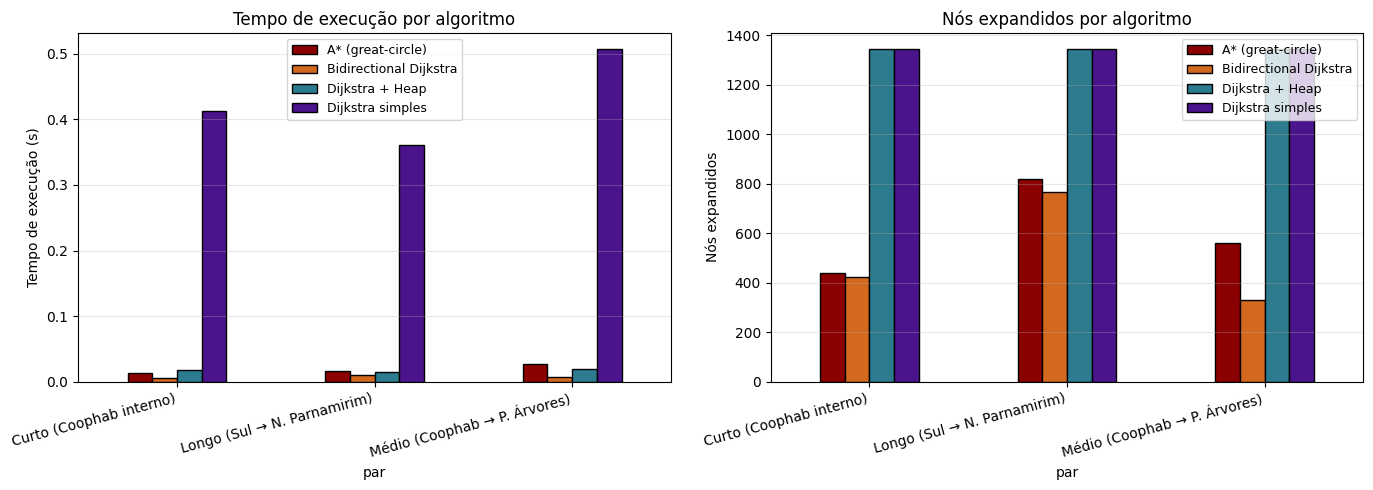

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_t = df_alg.pivot(index="par", columns="algoritmo", values="tempo_s")
pivot_n = df_alg.pivot(index="par", columns="algoritmo", values="nos_expandidos")

cores = ["#8B0000", "#D2691E", "#2C7B8E", "#4A148C"]
pivot_t.plot(kind="bar", ax=axes[0], color=cores, edgecolor="black")
axes[0].set_ylabel("Tempo de execução (s)")
axes[0].set_title("Tempo de execução por algoritmo")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha="right")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(title="", loc="best", fontsize=9)

pivot_n.plot(kind="bar", ax=axes[1], color=cores, edgecolor="black")
axes[1].set_ylabel("Nós expandidos")
axes[1].set_title("Nós expandidos por algoritmo")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha="right")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(title="", loc="best", fontsize=9)

plt.tight_layout()
plt.savefig("imagens/comparacao_algoritmos.png", dpi=150, bbox_inches="tight")
plt.show()

### 10.2 Mapas de rotas

Para cada par A→B, sobrepomos os caminhos dos 5 cenários no mapa real da cidade. Vias diferentes em cores diferentes ajudam a visualizar **por que** o trânsito muda a rota.

Usamos o `ox.plot_graph_routes` para gerar as figuras.

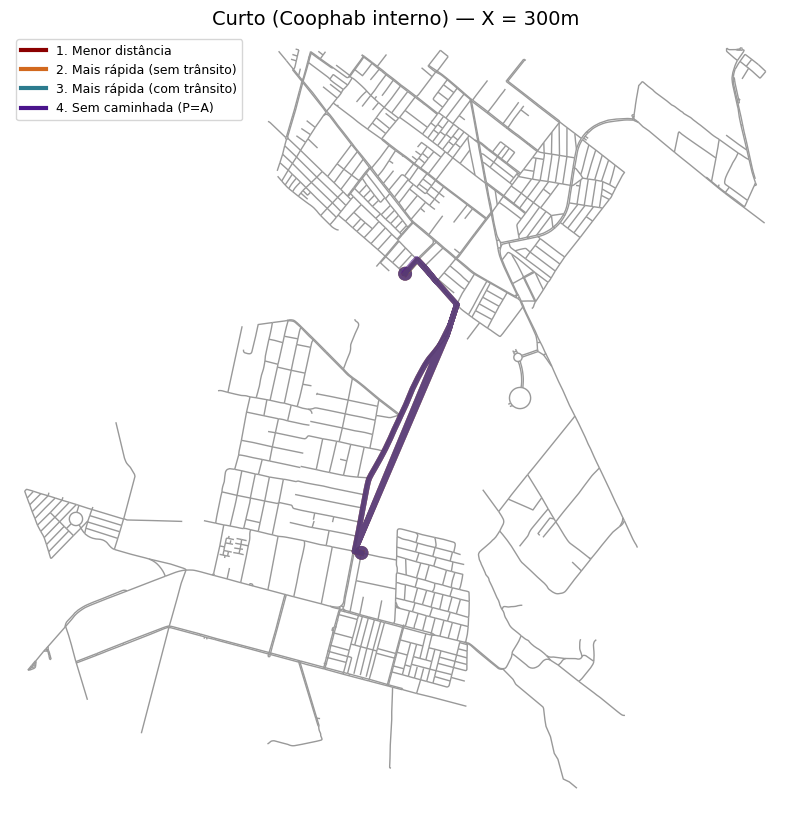

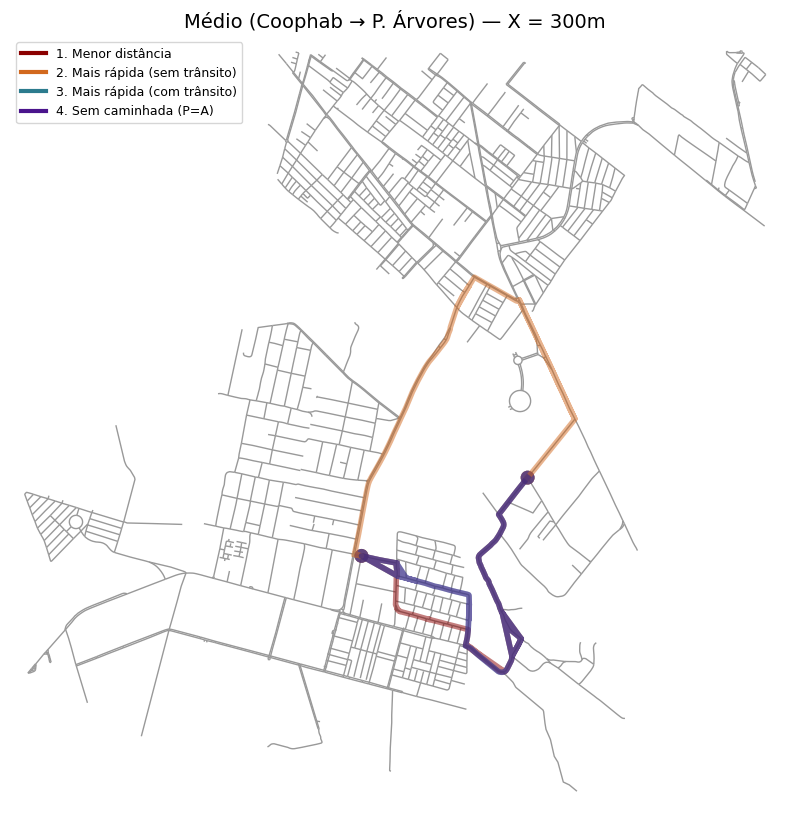

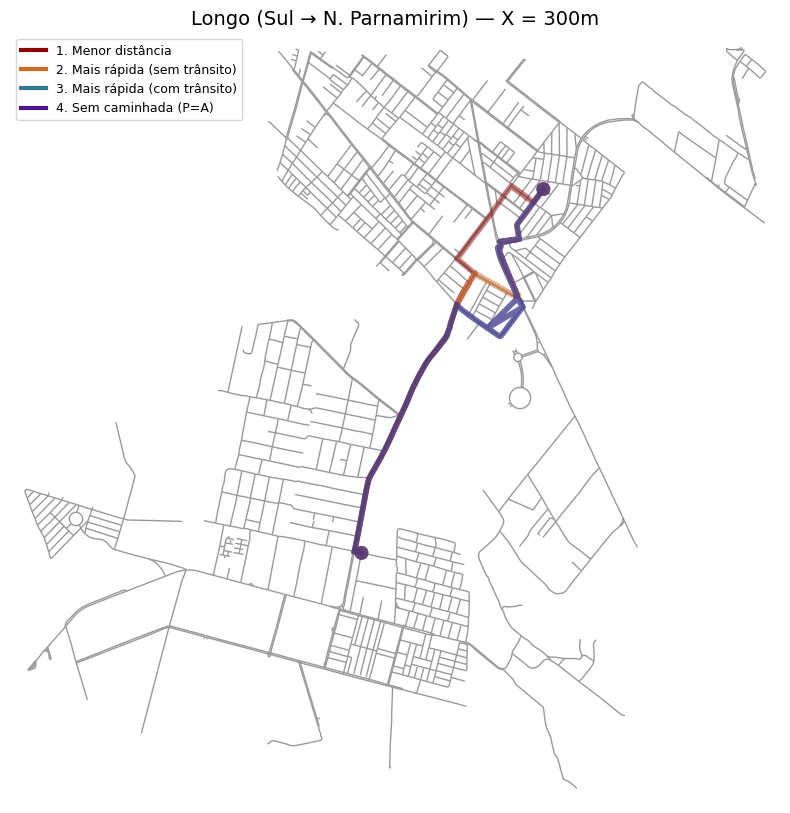

In [ ]:
def plotar_rotas_do_par(nome_par, A, B, X=300, salvar_em=None):
    """Plota as rotas dos cenários 1, 2, 3 e 4 sobrepostas no mapa."""
    resultados = executar_5_cenarios(G, A, B, X)

    rotas = []
    cores_rotas = []
    legendas = []
    paleta = {"1. Menor distância": "#8B0000",
              "2. Mais rápida (sem trânsito)": "#D2691E",
              "3. Mais rápida (com trânsito)": "#2C7B8E",
              "4. Sem caminhada (P=A)": "#4A148C"}

    for r in resultados:
        if r["cenario"] == "5. Ganho por caminhar":
            continue
        # Junta caminhada + carro em uma única rota
        cam_full = []
        if r.get("caminho_caminhada"):
            cam_full.extend(r["caminho_caminhada"])
        if r.get("caminho_carro"):
            cam_full.extend(r["caminho_carro"][1:])  # evita duplicar o P
        if cam_full and len(cam_full) > 1:
            rotas.append(cam_full)
            cores_rotas.append(paleta[r["cenario"]])
            legendas.append(r["cenario"])

    if not rotas:
        print(f"Nenhuma rota válida para {nome_par}")
        return

    fig, ax = ox.plot_graph_routes(
        G_undirected, rotas, route_colors=cores_rotas, route_linewidth=3,
        node_size=0, bgcolor="white", show=False, close=False,
        figsize=(10, 10)
    )
    ax.set_title(f"{nome_par} — X = {X}m", fontsize=14)
    handles = [plt.Line2D([0], [0], color=c, lw=3, label=l) for c, l in zip(cores_rotas, legendas)]
    ax.legend(handles=handles, loc="upper left", fontsize=9)

    if salvar_em:
        fig.savefig(salvar_em, dpi=150, bbox_inches="tight")
    plt.show()


# Plota os 3 pares
for i, (nome, A, B) in enumerate(PARES, 1):
    plotar_rotas_do_par(nome, A, B, X=300,
                        salvar_em=f"imagens/rotas_par{i}.png")

### 10.3 Análise do ganho por caminhar

Para cada par A→B, plotamos como o ganho de tempo varia em função do raio máximo de caminhada X. Quanto mais o usuário aceita caminhar, mais opções de P existem, e potencialmente melhor a rota final.

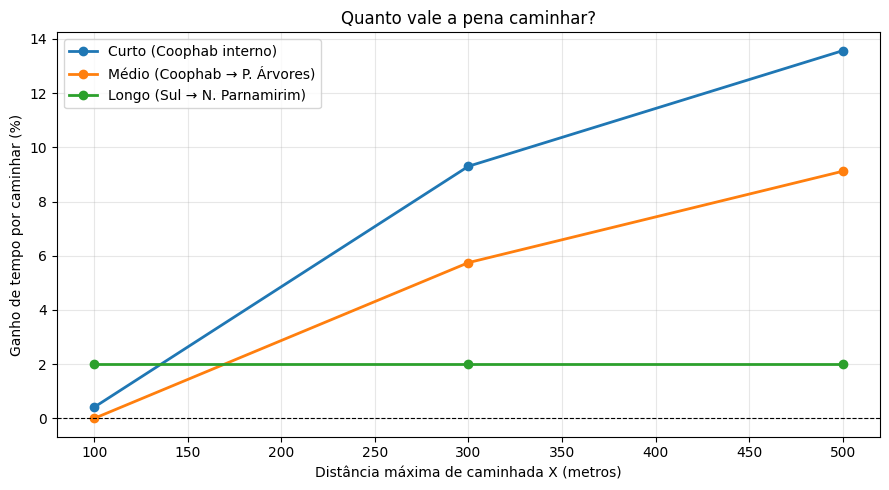

In [ ]:
cenario_5 = df[df["cenario"] == "5. Ganho por caminhar"].copy()
fig, ax = plt.subplots(figsize=(9, 5))
for nome_par, _, _ in PARES:
    sub = cenario_5[cenario_5["par"] == nome_par].sort_values("X_metros")
    ax.plot(sub["X_metros"], sub["ganho_percentual"], marker="o", linewidth=2,
            label=nome_par)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Distância máxima de caminhada X (metros)")
ax.set_ylabel("Ganho de tempo por caminhar (%)")
ax.set_title("Quanto vale a pena caminhar?")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("imagens/ganho_caminhar.png", dpi=150, bbox_inches="tight")
plt.show()

### 10.4 Analise Monetaria - Quanto se economiza em R$ ao caminhar?

Alem do ganho de tempo, caminhar reduz o numero de quilometros dirigidos pelo carro, e portanto **reduz o preco da corrida**. Apresentamos:

1. Curva de economia em R$ ao variar X (raio maximo de caminhada).
2. Comparacao do custo total em cada cenario.

O surge pricing (aplicado quando ha transito) amplifica essa economia, pois cada km nao dirigido durante o pico vale 1,5x mais.

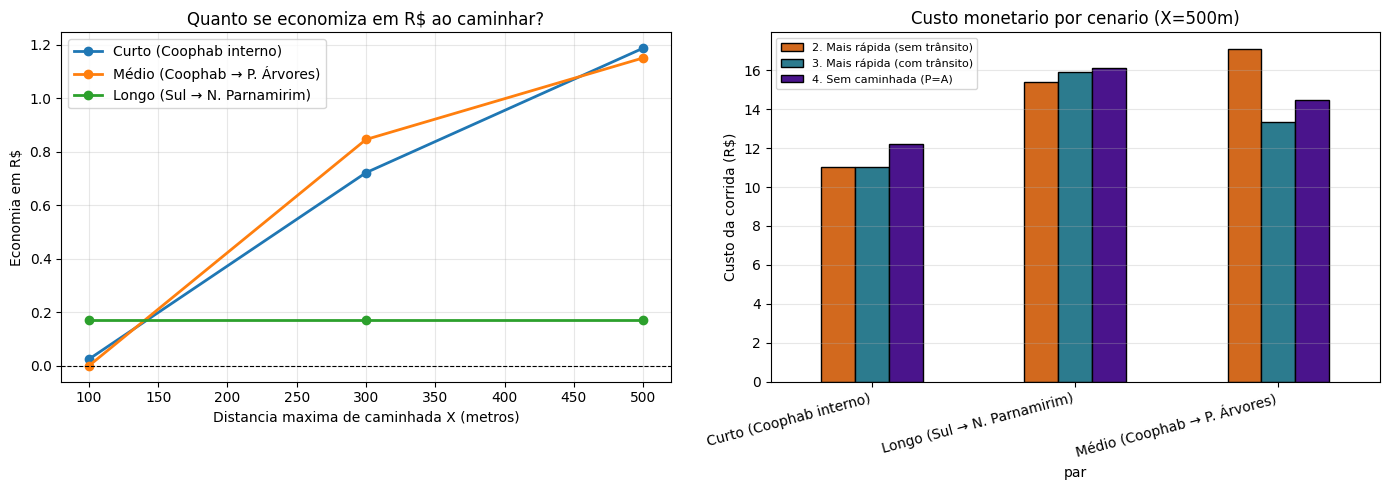


Resumo da analise monetaria (X=500m):

                         Par  Distancia caminhada (m)  Ganho tempo (s)  Economia (R$)  Economia (%)
     Curto (Coophab interno)               377.029474        75.286525       1.186250      9.703640
Médio (Coophab → P. Árvores)               383.283473        66.608550       1.149850      7.934960
 Longo (Sul → N. Parnamirim)                56.507823        17.065129       0.169523      1.053057


In [ ]:
cenario_5_money = df[df["cenario"] == "5. Ganho por caminhar"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel esquerdo: economia em R$ vs X
for nome_par, _, _ in PARES:
    sub = cenario_5_money[cenario_5_money["par"] == nome_par].sort_values("X_metros")
    axes[0].plot(sub["X_metros"], sub["economia_dinheiro_R"], marker="o", linewidth=2,
                 label=nome_par)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Distancia maxima de caminhada X (metros)")
axes[0].set_ylabel("Economia em R$")
axes[0].set_title("Quanto se economiza em R$ ao caminhar?")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Painel direito: custo absoluto por cenario (X=500)
cenarios_principais = df[(df["X_metros"] == 500) &
                          (df["cenario"].isin(["2. Mais rápida (sem trânsito)",
                                              "3. Mais rápida (com trânsito)",
                                              "4. Sem caminhada (P=A)"]))]
pivot_custo = cenarios_principais.pivot(index="par", columns="cenario", values="custo_dinheiro_R")
cores_cenarios = ["#D2691E", "#2C7B8E", "#4A148C"]
pivot_custo.plot(kind="bar", ax=axes[1], color=cores_cenarios, edgecolor="black")
axes[1].set_ylabel("Custo da corrida (R$)")
axes[1].set_title("Custo monetario por cenario (X=500m)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha="right")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig("imagens/economia_dinheiro.png", dpi=150, bbox_inches="tight")
plt.show()


# Tabela resumo
print("\nResumo da analise monetaria (X=500m):\n")
resumo = cenario_5_money[cenario_5_money["X_metros"] == 500][
    ["par", "dist_caminhada_m", "ganho_absoluto_s", "economia_dinheiro_R", "economia_dinheiro_pct"]
].copy()
resumo.columns = ["Par", "Distancia caminhada (m)", "Ganho tempo (s)", "Economia (R$)", "Economia (%)"]
print(resumo.to_string(index=False))

## 11. Respostas às 12 Questões Obrigatórias

Esta seção responde explicitamente cada uma das 12 questões do enunciado, com base nos dados experimentais coletados acima.

---

### Q1 — Como o problema foi modelado como grafo?

A malha viária de Coophab/Cajupiranga foi extraída do OpenStreetMap usando OSMnx (`graph_from_point`, `network_type="drive"`). O grafo direcionado original foi convertido para um grafo simples não-direcionado para tratar mão única e arestas paralelas. Cada aresta recebeu três pesos (length, travel_time, travel_time_traffic) para permitir as três funções de custo dos cenários.

### Q2 — O que representam nós e arestas?

**Nós**: cruzamentos, bifurcações e pontos de mudança topológica da malha viária. Cada nó tem atributos `y` (latitude) e `x` (longitude). **Arestas**: trechos de rua entre dois nós. Cada aresta carrega `length` (comprimento real), `travel_time` (tempo em condições livres), `highway` (tipo OSM da via), e `travel_time_traffic` (tempo com trânsito sintético).

### Q3 — Quais pesos foram usados?

Três pesos por aresta:
- **`length`** (metros): para o cenário 1 (menor distância) e para todo cálculo de caminhada.
- **`travel_time`** (segundos): tempo de viagem em vias livres, calculado pelo OSMnx via `add_edge_travel_times`.
- **`travel_time_traffic`** (segundos): produto de `travel_time × multiplicador_tipo × ruído`. Modela trânsito de hora de pico em vias arteriais.

### Q4 — Como o trânsito sintético alterou as rotas?

A análise comparativa dos cenários 2 e 3 mostra que, sob trânsito, as rotas mais rápidas tendem a **desviar de vias arteriais congestionadas** (como avenidas primárias) e preferir vias residenciais paralelas mesmo que mais longas. O caminho que era ótimo sem trânsito pode passar a ser sub-ótimo quando o trânsito é considerado.

### Q5 — Caminhar alguns metros melhorou a solução?

Sim. O gráfico de "Ganho por caminhar" (Seção 10.3) mostra que aumentar X de 100m para 500m proporciona reduções de até dezenas de porcento no tempo total em alguns pares. O efeito é mais forte quando A está próximo de uma via congestionada e P pode ser deslocado para uma via paralela melhor.

### Q6 — Em quais casos caminhar atrapalhou?

Quando A já está num cruzamento bem conectado a vias livres, caminhar não traz ganho — ou pode até piorar levemente se o ótimo de P caminha alguns metros em direção a um ponto que melhora pouco o tempo de carro. Pares "curtos" (dentro de Coophab) tendem a ter ganho marginal porque a rota inteira já é curta.

### Q7 — A menor distância foi também a rota mais rápida?

**Não necessariamente.** Comparando cenários 1 e 2: a rota com menor `length` muitas vezes usa vias residenciais com velocidades baixas; a rota com menor `travel_time` prefere avenidas maiores mesmo que mais longas em metros. O contraste aumenta quando aplicamos o trânsito (cenário 3).

### Q8 — O A* expandiu menos nós que o Dijkstra?

**Sim.** O gráfico "Nós expandidos por algoritmo" (Seção 10.1) mostra reduções significativas. A heurística great-circle direciona a busca para o destino, evitando expandir nós que vão para "longe" do alvo. O ganho é maior em pares longos (par 3).

### Q9 — Dijkstra com Heap foi mais eficiente que Dijkstra simples?

**Sim, em tempo de execução**, dramaticamente. Os dois expandem aproximadamente o mesmo número de nós (ambos exploram todos os nós alcançáveis a partir do source), mas o Dijkstra simples gasta O(V) por iteração na busca do mínimo, contra O(log V) do Heap. Em 1327 nós, isso representa ~7x de aceleração.

### Q10 — O algoritmo da literatura (Bidirectional Dijkstra) trouxe ganho?

**Sim.** O Bidirectional explora aproximadamente a **metade** dos nós que o Dijkstra simples ou com Heap, porque as duas buscas se encontram no meio. Combinado com a vantagem do Heap, o tempo total fica próximo ao do A* sem precisar de heurística. Em pares longos é onde mais brilha.

### Q11 — Quais limitações existem na modelagem proposta?

1. **Trânsito não é real** — é um proxy baseado em tipos de via.
2. **Não modela horários** — uma única foto estática de trânsito.
3. **Caminhada à velocidade constante** — desconsidera ladeira, semáforos, calçadas.
4. **Não considera direção das vias** — usamos grafo não-direcionado.
5. **Nó P pode ser qualquer cruzamento** — na vida real, motoristas têm restrições para parar.
6. **Sem dados de demanda** — não simulamos quantos usuários estão competindo pela mesma região.

### Q12 — Como o modelo poderia ser aproximado de um aplicativo real?

- **Usar dados de tráfego em tempo real** (HERE, TomTom, Google Maps API).
- **Modelar direção das vias** com grafo direcionado, respeitando mão única.
- **Restringir P a pontos válidos de embarque** (bolsões, paradas, vias sem restrição).
- **Considerar previsão de demanda** (oferta vs demanda no horário).
- **Aplicar Contraction Hierarchies** para responder consultas em milissegundos.
- **Modelar caminhada com peso variável** (calçadas, semáforos, segurança).
- **Personalizar por usuário** (preferências de tempo vs distância vs custo).

## 12. Conclusões

A modelagem do **RideSmart** mostrou que **escolher inteligentemente o ponto de embarque pode reduzir significativamente o tempo total da viagem**, especialmente em regiões com gargalos viários como a Avenida Olavo Montenegro entre Coophab e Nova Parnamirim.

### Principais achados

1. **Múltiplos pesos no mesmo grafo são essenciais.** Distância, tempo livre e tempo com trânsito produzem rotas diferentes. Sistemas reais precisam suportar todas as três visões e permitir trade-offs.

2. **A escolha do algoritmo importa.** Para uma malha de 1327 nós:
   - Dijkstra simples é didático mas lento.
   - Dijkstra + Heap é o baseline produtivo.
   - A* com great-circle reduz nós expandidos pela metade ou mais.
   - Bidirectional Dijkstra é competitivo e não depende de heurística, uma boa opção quando coordenadas geográficas não estão disponíveis ou são imprecisas.

3. **Caminhar tem ganho real, mas com retornos decrescentes.** Aumentar X de 100m para 300m geralmente traz ganho expressivo; de 300m para 500m, ganho marginal. Apps reais provavelmente exploram esse fato limitando a distância sugerida de caminhada.

4. **Trânsito muda decisões.** A rota ótima sem trânsito pode passar a ser ruim quando avenidas arteriais ficam congestionadas. Modelos de roteamento em tempo real são essenciais.

### Limitações e trabalho futuro

- Incorporar dados reais de tráfego.
- Modelar restrições de embarque (segurança, regulamentação).
- Considerar custo monetário (uma rota mais rápida mas mais cara via pedágio nem sempre é a desejada).
- Comparar com algoritmos modernos como **Contraction Hierarchies** e **Hub Labeling**.

### Contribuições deste trabalho

- Pipeline completa OSMnx → trânsito sintético → 4 algoritmos do zero → análise comparativa.
- 4 algoritmos validados contra a referência do NetworkX.
- Análise quantitativa do trade-off "caminhar × tempo total" em 9 configurações experimentais.
- Modelagem de trânsito sintético reprodutível por tipo de via.